# MC 02 — Forecasting Model Comparison

Compare all Forecasting candidates using the same development metrics.

In [1]:

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "configs" / "model_comparison.yaml"


In [2]:
import matplotlib.pyplot as plt
from src.ontario_peak_risk.model_comparison.io import load_config, load_model_reports
from src.ontario_peak_risk.model_comparison.metrics import (
    forecasting_global_table,
    combine_group_metrics,
)
from src.ontario_peak_risk.model_comparison.plotting import (
    forecasting_global_metrics_plot,
    forecasting_percentage_metrics_plot,
    metric_by_fold_plot,
    metric_by_horizon_plot,
    fsa_heatmap,
)

config, project_root = load_config(CONFIG_PATH)
reports = load_model_reports(config, project_root, "forecasting")

global_table = forecasting_global_table(reports)
fold_table = combine_group_metrics(reports, "fold_metrics")
fsa_table = combine_group_metrics(reports, "fsa_metrics")
horizon_table = combine_group_metrics(reports, "horizon_metrics")

display(global_table.sort_values("mae"))


,model_key,model,family,mae,rmse,mape,wape,bias,abs_bias,n_observations
1,random_forest,Random Forest Regressor,Bagging,542.255101,926.184858,5.552180,5.959380,-125.312178,125.312178,2519424
4,lightgbm,LightGBM Regressor,Gradient Boosting,580.835973,1044.368141,5.735130,6.383384,-213.040484,213.040484,2519424
2,sarimax,SARIMAX Rolling,Statistical Time Series,583.635455,929.486636,6.089956,6.414150,-164.621729,164.621729,2519424
3,xgboost,XGBoost Regressor,Gradient Boosting,606.265878,1106.771204,5.929867,6.662859,-251.046293,251.046293,2519424
0,seasonal_naive,Seasonal Naive,Baseline,612.048608,994.292504,6.589649,6.726411,-0.837658,0.837658,2519424


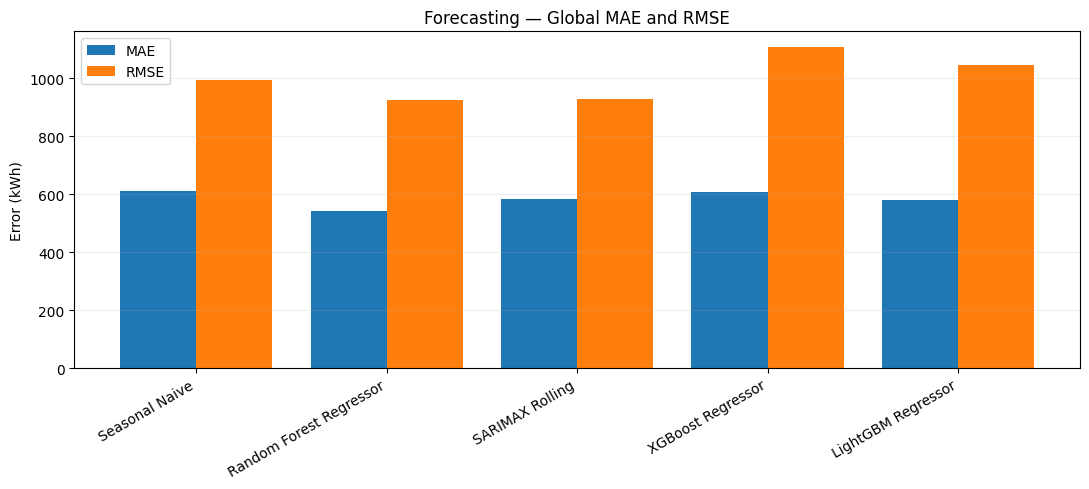

In [3]:
forecasting_global_metrics_plot(global_table); plt.show()

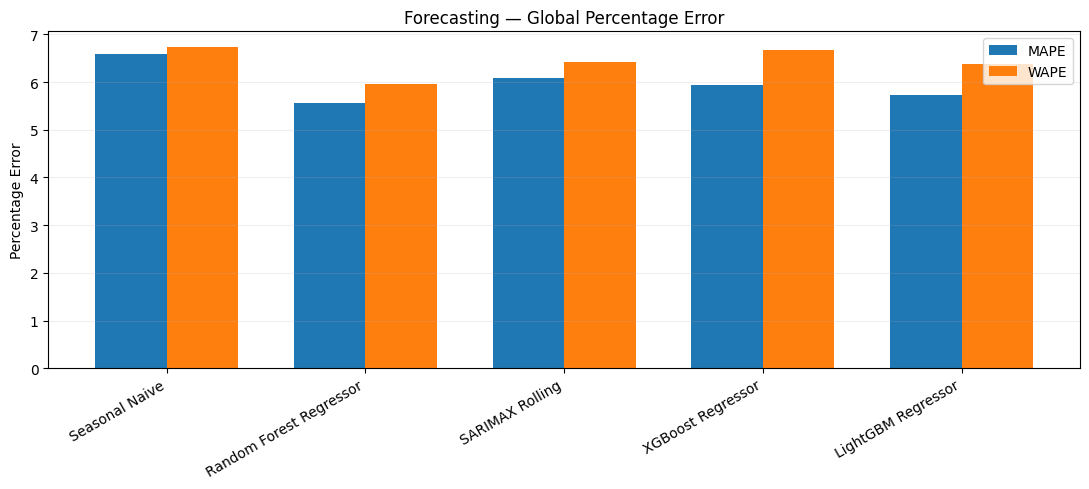

In [4]:
forecasting_percentage_metrics_plot(global_table); plt.show()

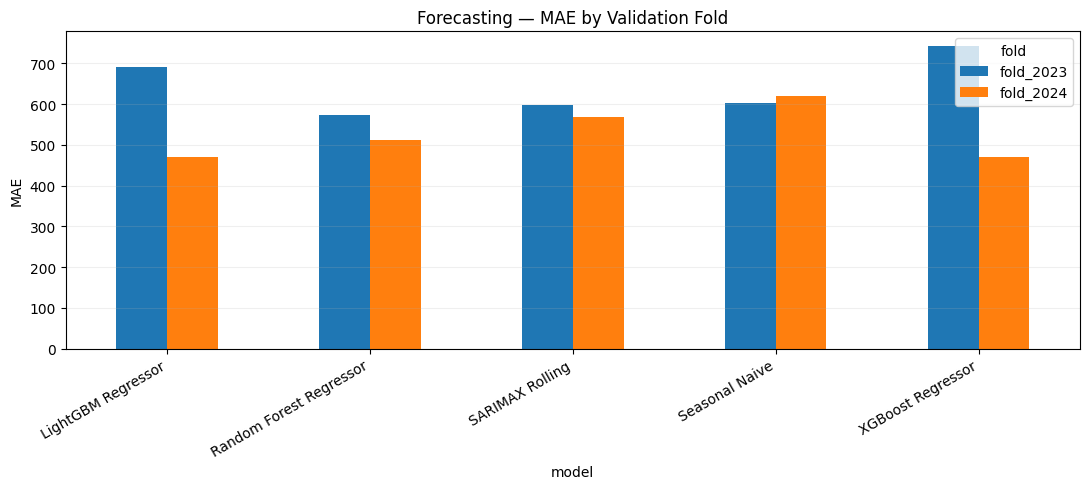

In [5]:
metric_by_fold_plot(fold_table, "mae", "Forecasting — MAE by Validation Fold"); plt.show()

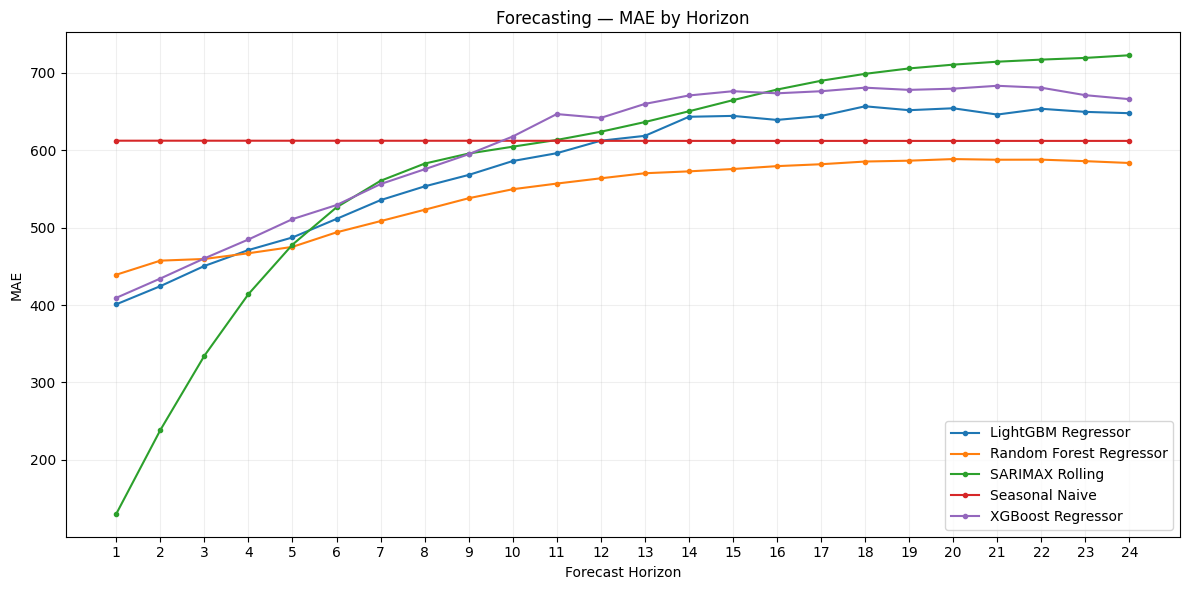

In [6]:
metric_by_horizon_plot(horizon_table, "mae", "Forecasting — MAE by Horizon"); plt.show()

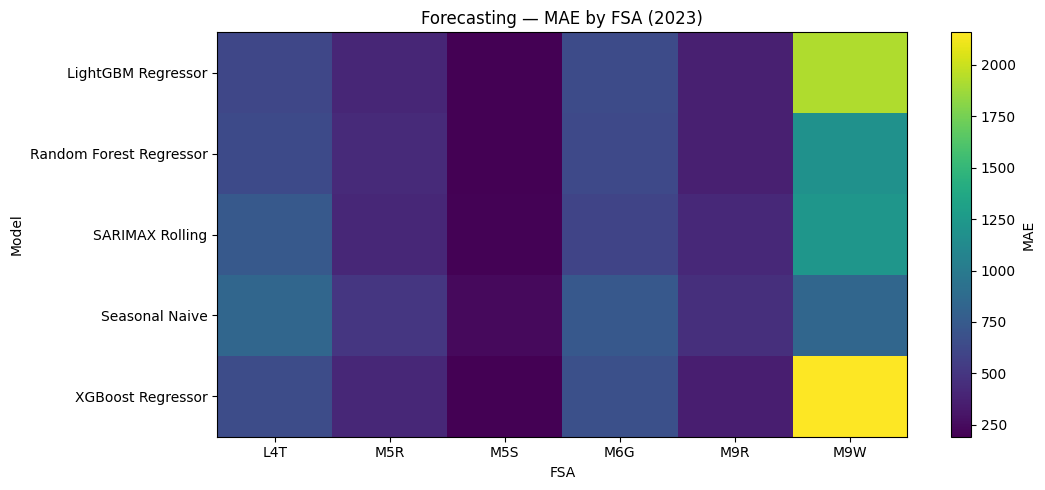

In [7]:
fsa_heatmap(fsa_table, "mae", "fold_2023", "Forecasting — MAE by FSA (2023)"); plt.show()

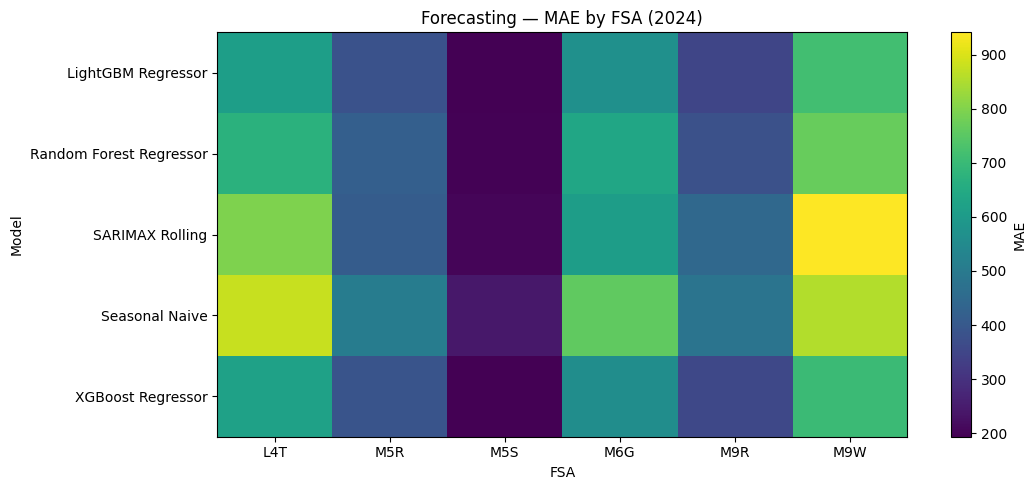

In [8]:
fsa_heatmap(fsa_table, "mae", "fold_2024", "Forecasting — MAE by FSA (2024)"); plt.show()